**6.7. Statistics - Hands-on Session - Part 1**

In this session, we will apply statistical concepts using Python.
We will cover:
1. Loading a dataset
2. Measures of Central Tendency (Mean, Median, Mode)
3. Data Distributions & Skewness
4. Measures of Spread (Range, Variance, Standard Deviation, IQR)
5. Descriptive Statistics

**Dataset:** We will use the `tips` dataset built into Seaborn. 
It represents restaurant bills and includes data on total bill, tip amount, sex, smoker status, day, time, and size.

---

In [1]:
# install the required libraries
%pip install -q pandas numpy matplotlib seaborn

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
# importing the required dependencies
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [26]:
sns.set_theme(style = "whitegrid")
sns.set_palette("coolwarm")

**Loading a dataset**

In [29]:
data = sns.get_dataset_names()

In [4]:
df = sns.load_dataset("tips")
print(df)

     total_bill   tip     sex smoker   day    time  size
0         16.99  1.01  Female     No   Sun  Dinner     2
1         10.34  1.66    Male     No   Sun  Dinner     3
2         21.01  3.50    Male     No   Sun  Dinner     3
3         23.68  3.31    Male     No   Sun  Dinner     2
4         24.59  3.61  Female     No   Sun  Dinner     4
..          ...   ...     ...    ...   ...     ...   ...
239       29.03  5.92    Male     No   Sat  Dinner     3
240       27.18  2.00  Female    Yes   Sat  Dinner     2
241       22.67  2.00    Male    Yes   Sat  Dinner     2
242       17.82  1.75    Male     No   Sat  Dinner     2
243       18.78  3.00  Female     No  Thur  Dinner     2

[244 rows x 7 columns]


In [31]:
print(df.head(5))

   total_bill   tip     sex smoker  day    time  size
0       16.99  1.01  Female     No  Sun  Dinner     2
1       10.34  1.66    Male     No  Sun  Dinner     3
2       21.01  3.50    Male     No  Sun  Dinner     3
3       23.68  3.31    Male     No  Sun  Dinner     2
4       24.59  3.61  Female     No  Sun  Dinner     4


In [6]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 244 entries, 0 to 243
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype   
---  ------      --------------  -----   
 0   total_bill  244 non-null    float64 
 1   tip         244 non-null    float64 
 2   sex         244 non-null    category
 3   smoker      244 non-null    category
 4   day         244 non-null    category
 5   time        244 non-null    category
 6   size        244 non-null    int64   
dtypes: category(4), float64(2), int64(1)
memory usage: 7.4 KB
None


**Measure of central tendency**

In [7]:
print(df.columns)

Index(['total_bill', 'tip', 'sex', 'smoker', 'day', 'time', 'size'], dtype='object')


In [8]:
col = df['total_bill']

In [34]:
mode_v = col.mode()
print(type(mode_v))

<class 'pandas.core.series.Series'>


Mean of tip $19.79
Median of tip $17.80
Mode of tip $13.42


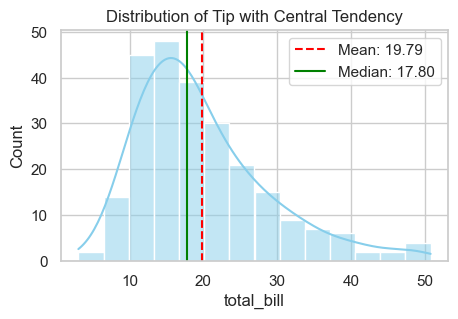

In [36]:
col = df["total_bill"]

mean_val = np.mean(col)
median_val = np.median(col)
mode_val = col.mode()[0]

print(f"Mean of tip ${mean_val:.2f}")
print(f"Median of tip ${median_val:.2f}")
print(f"Mode of tip ${mode_val:.2f}")

# visualize the histogram to understand the distribution of "total_bill" column
plt.figure(figsize=(5, 3)) 
sns.histplot(col, kde=True, color="skyblue")
plt.axvline(mean_val, color="red", linestyle="--", label=(f"Mean: {mean_val:.2f}"))
plt.axvline(median_val, color="green", linestyle="-", label=f"Median: {median_val:.2f}")
plt.legend()
plt.title("Distribution of Tip with Central Tendency")
plt.show()

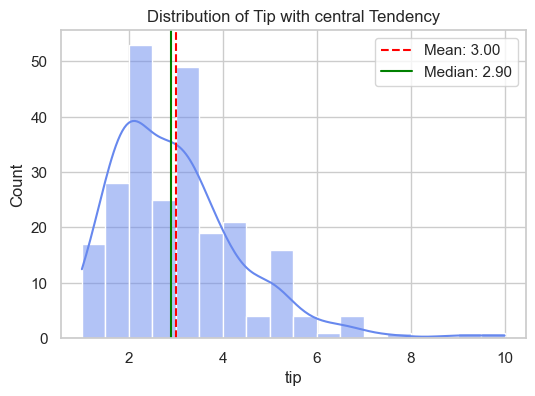

In [43]:
col = df["tip"]

mean_val = np.mean(col)
median_val = np.median(col)
mode_val = col.mode()[0]

plt.figure(figsize = (6,4))
sns.histplot(col, kde = True)
plt.title("Distribution of Tip with central Tendency")
plt.axvline(mean_val, color = "red", linestyle = "--", label = f"Mean: {mean_val:.2f}")
plt.axvline(median_val, color = "green", label = f"Median: {median_val:.2f}")
plt.legend()

plt.show()


Mean of tip $3.00
Median of tip $2.90
Mode of tip $2.00


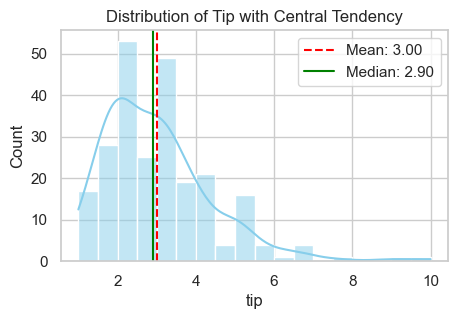

In [44]:
col = df["tip"]

mean_val = np.mean(col)
median_val = np.median(col)
mode_val = col.mode()[0]

print(f"Mean of tip ${mean_val:.2f}")
print(f"Median of tip ${median_val:.2f}")
print(f"Mode of tip ${mode_val:.2f}")

# visualize the histogram to understand the distribution of "total_bill" column
plt.figure(figsize=(5, 3))
sns.histplot(col, kde=True, color="skyblue")
plt.axvline(mean_val, color="red", linestyle="--",
            label=(f"Mean: {mean_val:.2f}"))
plt.axvline(median_val, color="green", linestyle="-",
            label=f"Median: {median_val:.2f}")
plt.legend()
plt.title("Distribution of Tip with Central Tendency")
plt.show()

Mean of total_bill: 3.00
Median of total_bill: 2.90
Mode of total_bill: 2.00


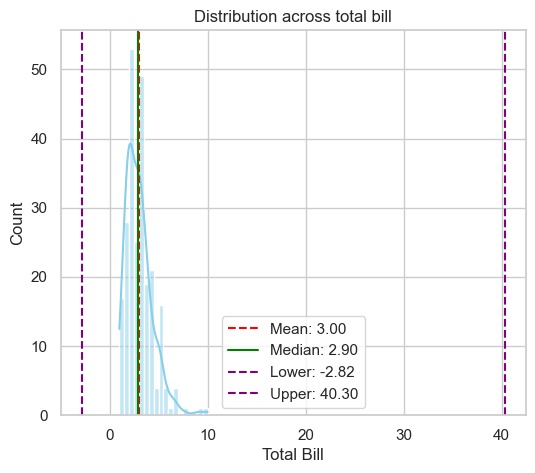

In [11]:
mean_value = np.mean(col)
median_value = np.median(col)
mode_value = col.mode()[0]

Q1 = df['total_bill'].quantile(0.25)
Q3 = df['total_bill'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Split normal vs outliers
normal = df[(df['total_bill'] >= lower_bound) & (df['total_bill'] <= upper_bound)]
outliers = df[(df['total_bill'] < lower_bound) | (df['total_bill'] > upper_bound)]

print(f"Mean of total_bill: {mean_value:.2f}")
print(f"Median of total_bill: {median_value:.2f}")
print(f"Mode of total_bill: {mode_value:.2f}")

plt.figure(figsize=(6,5))
sns.histplot(col, color="skyblue", kde=True)
plt.axvline(mean_value, linestyle = "--", color = "red", label = f"Mean: {mean_value:.2f}")
plt.axvline(median_value, color="green",
            label=f"Median: {median_value:.2f}")

# Add outlier boundaries
plt.axvline(lower_bound, color="purple", linestyle="--",
            label=f"Lower: {lower_bound:.2f}")
plt.axvline(upper_bound, color="purple", linestyle="--",
            label=f"Upper: {upper_bound:.2f}")

plt.title("Distribution across total bill")
plt.xlabel("Total Bill")
plt.ylabel("Count")

plt.legend()

In [12]:
print(df['total_bill'].value_counts(ascending=False))

total_bill
13.42    3
21.01    2
20.69    2
10.33    2
10.34    2
        ..
29.03    1
27.18    1
22.67    1
17.82    1
18.78    1
Name: count, Length: 229, dtype: int64


**Measure of Spread**

#### Spread tells us how scattered the data is around the center.

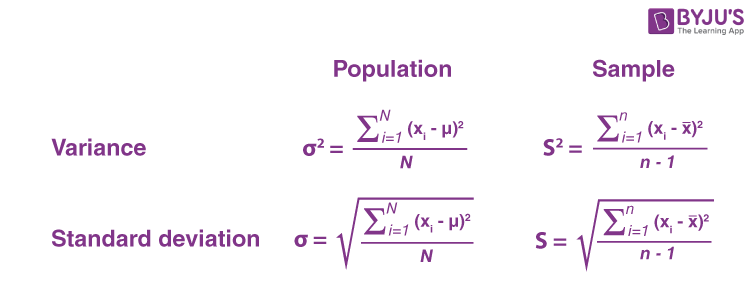

In [13]:
# Range
data_range = col.max() - col.min()
print(f"Range: {data_range:.2f}")

# Variance
variance = np.var(col)
print(f"Variance: {variance:.2f}")

#STD
std_dev = np.std(col)
print(f"STD: {std_dev:.2f}")

#IQR
Q1 = np.percentile(col, 25)
Q3 = np.percentile(col, 75)

IQR = Q3 - Q1
print(f"IQR: {IQR:.2f}")

Range: 9.00
Variance: 1.91
STD: 1.38
IQR: 1.56


**Summary Statistics (df.describe)**

- Descriptive Stats
- Predictive Stats
- Prescriptive Stats

In [14]:
df.describe()

,total_bill,tip,size
count,244.000000,244.000000,244.000000
mean,19.785943,2.998279,2.569672
std,8.902412,1.383638,0.951100
min,3.070000,1.000000,1.000000
25%,13.347500,2.000000,2.000000
50%,17.795000,2.900000,2.000000
75%,24.127500,3.562500,3.000000
max,50.810000,10.000000,6.000000


**Data Distribution and Skewness**

In [15]:
print(df['tip'].skew())
print(df['total_bill'].skew())

# Inteprepation: When value greater than 0 == Tail is longer on the right, clustered values on the left
# Inteprepation: When value equal 0 == Balanced skewness
# Inteprepation: When value less than 0 == Tail is longer on the left, clustered values on the right

1.4654510370979401
1.1332130376158205


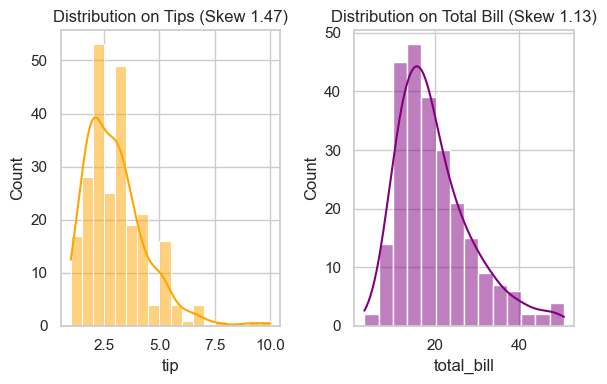

In [16]:
plt.figure(figsize=(6,4))

plt.subplot(1,2,1)
sns.histplot(df['tip'], kde=True, color="orange")
plt.title(f"Distribution on Tips (Skew {df['tip'].skew():.2f})")

plt.subplot(1,2,2)
sns.histplot(df['total_bill'], kde=True, color="purple")
plt.title(f"Distribution on Total Bill (Skew {df['total_bill'].skew():.2f})")

plt.tight_layout()

**Outlier Detection**

#### Using a Box Plot

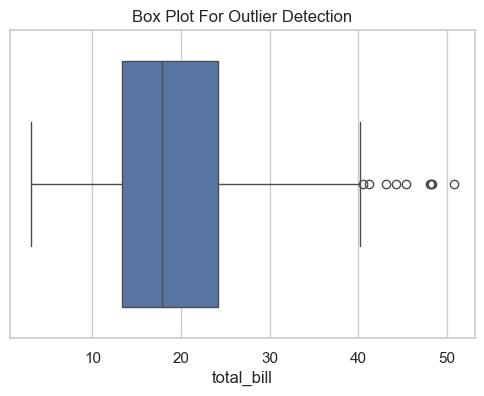

In [17]:
plt.figure(figsize=(6,4))
sns.boxplot(x=df['total_bill'])
plt.title("Box Plot For Outlier Detection")

plt.show()

#### Using a formula

In [18]:
Q1 = df["total_bill"].quantile(.25)
Q3 = df["total_bill"].quantile(.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

print(f"Lower Bound: {lower_bound:.2f}")
print(f"Upper Bound: {upper_bound:.2f}")

Lower Bound: -2.82
Upper Bound: 40.30


In [19]:
outlier = df[(df['total_bill'] < lower_bound) | (df['total_bill'] > upper_bound)]
outlier

,total_bill,tip,sex,smoker,day,time,size
59,48.27,6.73,Male,No,Sat,Dinner,4
102,44.30,2.50,Female,Yes,Sat,Dinner,3
142,41.19,5.00,Male,No,Thur,Lunch,5
156,48.17,5.00,Male,No,Sun,Dinner,6
170,50.81,10.00,Male,Yes,Sat,Dinner,3
182,45.35,3.50,Male,Yes,Sun,Dinner,3
184,40.55,3.00,Male,Yes,Sun,Dinner,2
197,43.11,5.00,Female,Yes,Thur,Lunch,4
212,48.33,9.00,Male,No,Sat,Dinner,4


**Correlation Analysis**

            total_bill       tip      size
total_bill    1.000000  0.675734  0.598315
tip           0.675734  1.000000  0.489299
size          0.598315  0.489299  1.000000


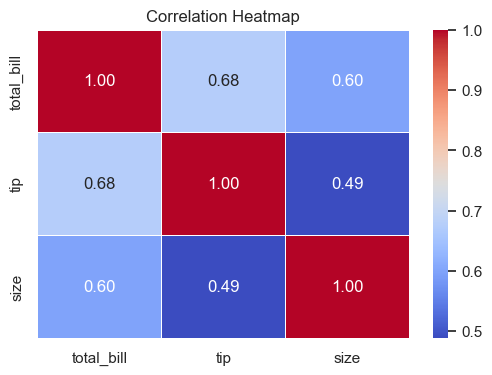

0.6757341092113648


In [24]:
numerical_df = df.select_dtypes(include=np.number)
corr_matrix = numerical_df.corr()

print(corr_matrix)

plt.figure(figsize=(6,4))
sns.heatmap(corr_matrix, annot=True, linecolor="white", cmap = "coolwarm", linewidths=.5, fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()

print(f"{corr_matrix.loc['total_bill', 'tip']}")